<a href="https://colab.research.google.com/github/OlyaP12/dsp-labs-hse/blob/main/Lab_work_%E2%84%961_Firsova_Olga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <center> Практические задания по цифровой обработке сигналов </center>
# <center> Первая лабораторная работа </center>


В данной работе Вы познакомитесь с основными методами работы с аудиоданными в Python. Разбересь в том, как работает свертка, и примените пару интересных фильтров.

# Задание 1. Работа с аудиофайлами в Python (1 балл)

## Теория

Звук - это аналоговый сигнал. То есть он является непрерывным по времени и по значениям. Для того, чтобы работать со звуком на цифровом устройстве, надо преобразовать его в цифровое представление. Для этого надо разделить непрерывный сигнал на промежутки времени (дискретизация сигнала) и разбить непрерывные значения на интервалы (квантование сигнала). Выбраные параметры дискретизации и квантования сигнала напрямую влияют на качество цифрового сигнала.

<!--
## Практика

1. Что хранится в .wav файле? Как узнать параметры дискретизации и квантования .wav файла?

2. Запишите аудиофайл со своим голосом. Загрузите его. Попробуйте поменять ему частоту дискретизации. Нарисуйте форму волны считанного файла. Воспроизведите полученные сигналы. При какой частоте дискретизации становится невозможно разобрать человеческую речь?   

3. Чем .wav отличается от других кодеков, например .mp3 или .ogg? -->


<!-- ### Подсказка

Записать цифровой сигнал можно при помощи, например, [Audacity](https://www.audacityteam.org) или [Adobe Audition](https://www.adobe.com/ru/products/audition.html). Для считывания файлов воспользуйтесь библиотекой [scipy](https://www.scipy.org) или [librosa](https://librosa.org/doc/latest/index.html). Для воспроизведения аудиофайла удобно использовать класс Audio из модуля IPython.display, а для отрисовки - matplotlib. -->

In [1]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

### 1. Что хранится в .wav файле? Как узнать параметры дискретизации и квантования .wav файла?

В .wav файле хранится цифровое представление звукового сигнала в несжатом виде. Это значит, что файл содержит последовательность отсчётов звуковой волны, полученных после дискретизации (разбиения непрерывного сигнала по времени) и квантования (округления амплитуды до ближайшего уровня). Помимо самих отсчётов, в заголовке файла записаны служебные данные: частота дискретизации (например, 44100 Гц), разрядность квантования (обычно 8, 16, 24 или 32 бита на отсчёт), количество каналов (моно или стерео), а также общая длина записи.

Подключаемся к гугл-диску

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Загружаем аудиофайл с собственным голосом

In [3]:
my_audio = "/content/drive/MyDrive/DSP_Labs/my_audio.wav"

In [4]:
import wave

with wave.open(my_audio, "rb") as wav_file:
    n_channels = wav_file.getnchannels()
    framerate = wav_file.getframerate()
    n_frames = wav_file.getnframes()
    sampwidth = wav_file.getsampwidth()
    duration = n_frames / framerate

print("Каналы:", n_channels)
print("Частота дискретизации:", framerate, "Гц")
print("Разрядность квантования:", sampwidth * 8, "бит")
print("Количество отсчётов:", n_frames)
print("Длительность:", duration, "секунд")

Каналы: 1
Частота дискретизации: 44100 Гц
Разрядность квантования: 16 бит
Количество отсчётов: 129024
Длительность: 2.9257142857142857 секунд


### 2. Запишите аудиофайл со своим голосом. Загрузите его. Попробуйте поменять ему частоту дискретизации. Нарисуйте форму волны считанного файла. Воспроизведите полученные сигналы. При какой частоте дискретизации становится невозможно разобрать человеческую речь?

**Подсказка**

Записать цифровой сигнал можно при помощи, например, [Audacity](https://www.audacityteam.org) или [Adobe Audition](https://www.adobe.com/ru/products/audition.html). Для считывания файлов воспользуйтесь библиотекой [scipy](https://www.scipy.org) или [librosa](https://librosa.org/doc/latest/index.html). Для воспроизведения аудиофайла удобно использовать класс Audio из модуля IPython.display, а для отрисовки - matplotlib.

In [5]:
import IPython.display as ipd

ipd.Audio(my_audio)

Исходная частота дискретизации: 44100


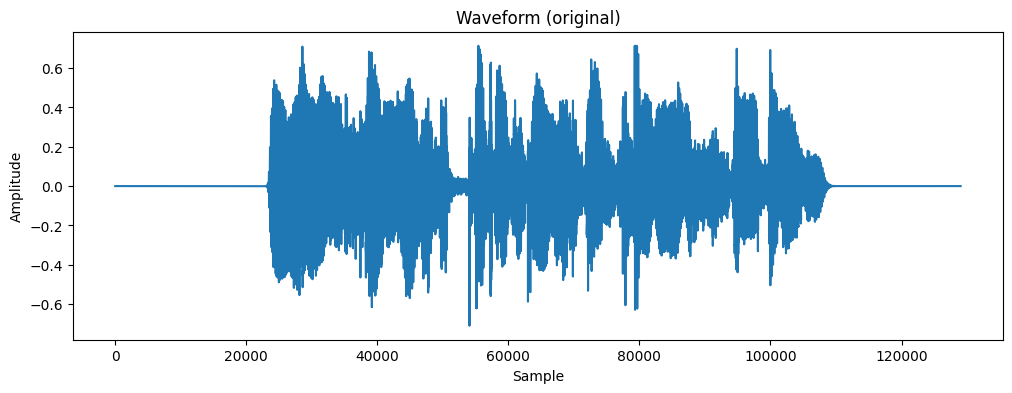

In [6]:
import librosa
from IPython.display import Audio

data, sample_freq = librosa.load(my_audio, sr=None)
print("Исходная частота дискретизации:", sample_freq)

plt.figure(figsize=(12, 4))
plt.plot(data)
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("Waveform (original)")
plt.show()

In [7]:
freq = 16000
rescaled_audio = librosa.resample(data, target_sr=freq, orig_sr=sample_freq)
Audio(data=rescaled_audio, rate=freq)

In [8]:
freq = 10000
rescaled_audio = librosa.resample(data, target_sr=freq, orig_sr=sample_freq)
Audio(data=rescaled_audio, rate=freq)

In [9]:
freq = 5000
rescaled_audio = librosa.resample(data, target_sr=freq, orig_sr=sample_freq)
Audio(data=rescaled_audio, rate=freq)

In [10]:
freq = 4000
rescaled_audio = librosa.resample(data, target_sr=freq, orig_sr=sample_freq)
Audio(data=rescaled_audio, rate=freq)

In [11]:
freq = 3000
rescaled_audio = librosa.resample(data, target_sr=freq, orig_sr=sample_freq)
Audio(data=rescaled_audio, rate=freq)

На 5000 Гц ещё как-то можно разобрать слова (с трудом), если прислушиваться, а вот при частоте 4000 Гц и ниже уже совсем совсем проблематично разобрать человеческую речь

### 3. Чем .wav отличается от других кодеков, например .mp3 или .ogg?

Формат .wav отличается от других тем, что в нём отсутствует сжатие. Звук сохраняется в исходном виде, без потерь, что обеспечивает максимальную точность и чистоту записи, но делает файлы тяжёлыми. В сжатых же форматах, таких как .mp3 или .ogg, применяется, так сказать,компромисс — часть данных отбрасывается, чтобы уменьшить размер, при этом качество остаётся достаточно высоким. Поэтому .wav и используют в профессиональной сфере — при озвучке, записи музыки, и так далее, где важен идеальный и чистый звук, а .mp3 мы чаще всего встречаем в повседневной жизни, так как такой формат подходит для хранения и распространения большого количества аудио, при этом мы минимально теряем качество

# Задание 2. Гармонические сигналы (1 балл)

## Теория
[Гармонические колебания](https://ru.wikipedia.org/wiki/Гармонические_колебания) -  колебания, при которых физическая величина изменяется с течением времени по гармоническому (синусоидальному/косинусоидальному) закону.

В общем случае гармонические колебания задаются формулой:

$$y=A \cos(\omega t+\varphi_0)$$

где $А$ - это амплитуда, $\omega$ – циклическая частота (радиан/с), $\varphi$ - фаза (сдвиг), $t$ – время.


In [12]:
# Сначала определим функцию для отрисовки сигнала с хорошим масштабом и сеткой
# Это поможет легче анализировать сигнал
def draw_signal(data, figsize=(14, 14)):
    plt.figure(figsize=figsize)
    plt.plot(data, linewidth=2)
    plt.minorticks_on()
    plt.xticks(np.arange(0, 1000, step=100))
    plt.yticks(np.arange((data.min().round())//10*10,
                         (data.max().round())//10*10+10, step=5))
    plt.grid(which='major',
        color = 'k',
        linewidth = 1)
    plt.grid(which='minor',
        color = 'k',
        linestyle = ':')
    plt.show()

In [13]:
resources = "/content/drive/MyDrive/DSP_Labs/resources"

In [14]:
# Читаем данные с подготовленными сигналами
import pickle
with open(f"{resources}/data.pickle", "rb") as f:
    test_data = pickle.load(f)
# Теперь можно приступать к практике!

## Практика

Постройте графики трех сигналов a, b и c из test_data['task2']. Попробуйте подобрать коэффициенты для этих сигналов. Сгенерируйте сигналы (1000 отсчетов) с подобранными коэффициентами. Постройте графики сгенерированных сигналов и пройдите тест на схожесть с оригинальным.


Подсказка. Фаза, период и амплитуда сигнала - целочисленные. Для генерации пользуйтесь библиотекой numpy и функциями arange, sin, cos.

### Сигнал ***a***

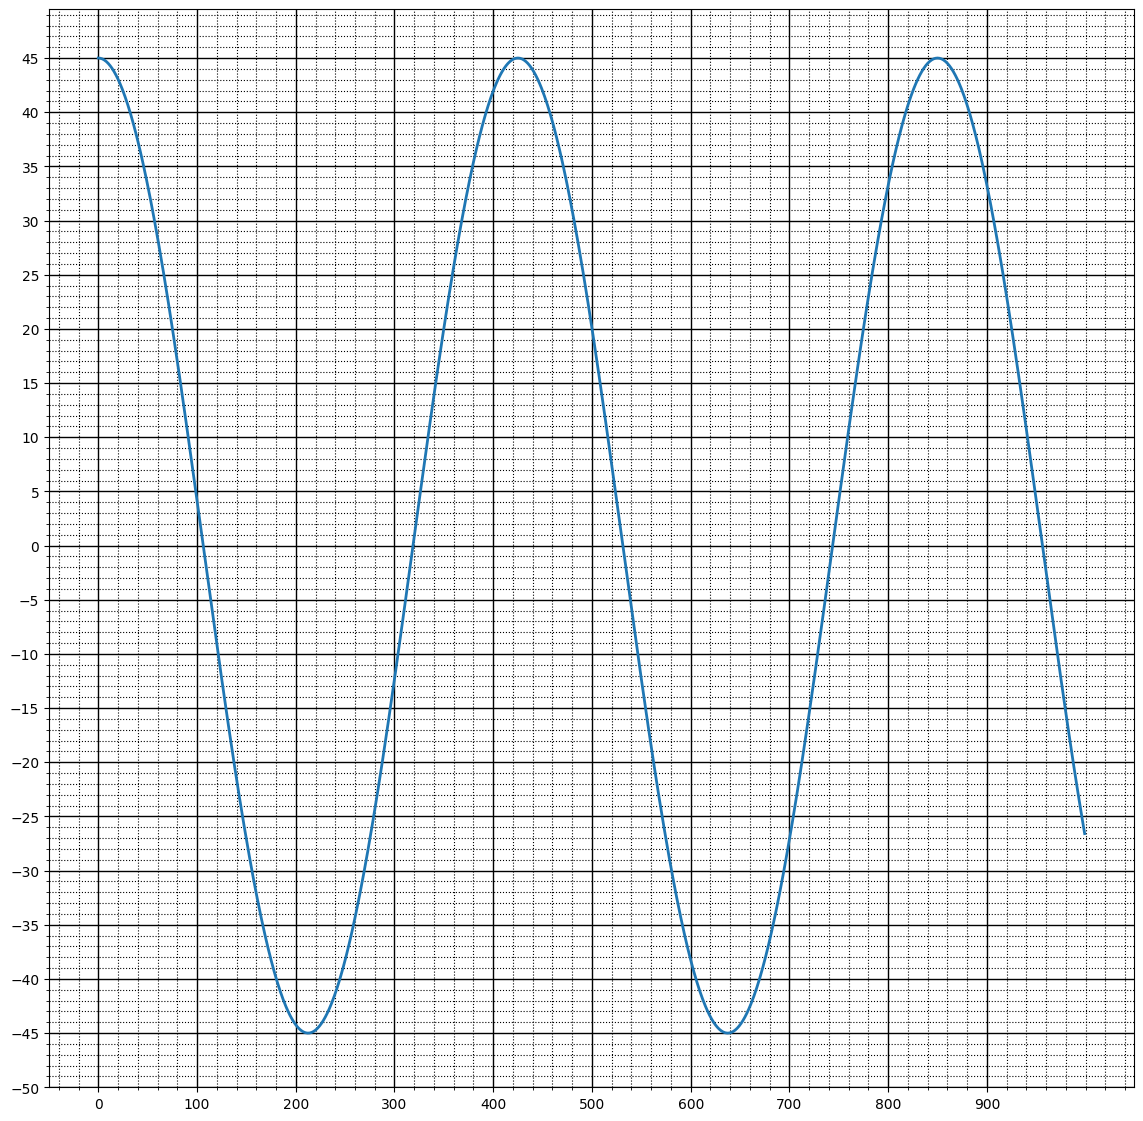

In [15]:
draw_signal(test_data['task2']['a'])

In [16]:
x = np.arange(0, 1000)
A = 45
phi = 0
T = 425
w = (2 * np.pi) / T
a = A * np.cos(w * x + phi)

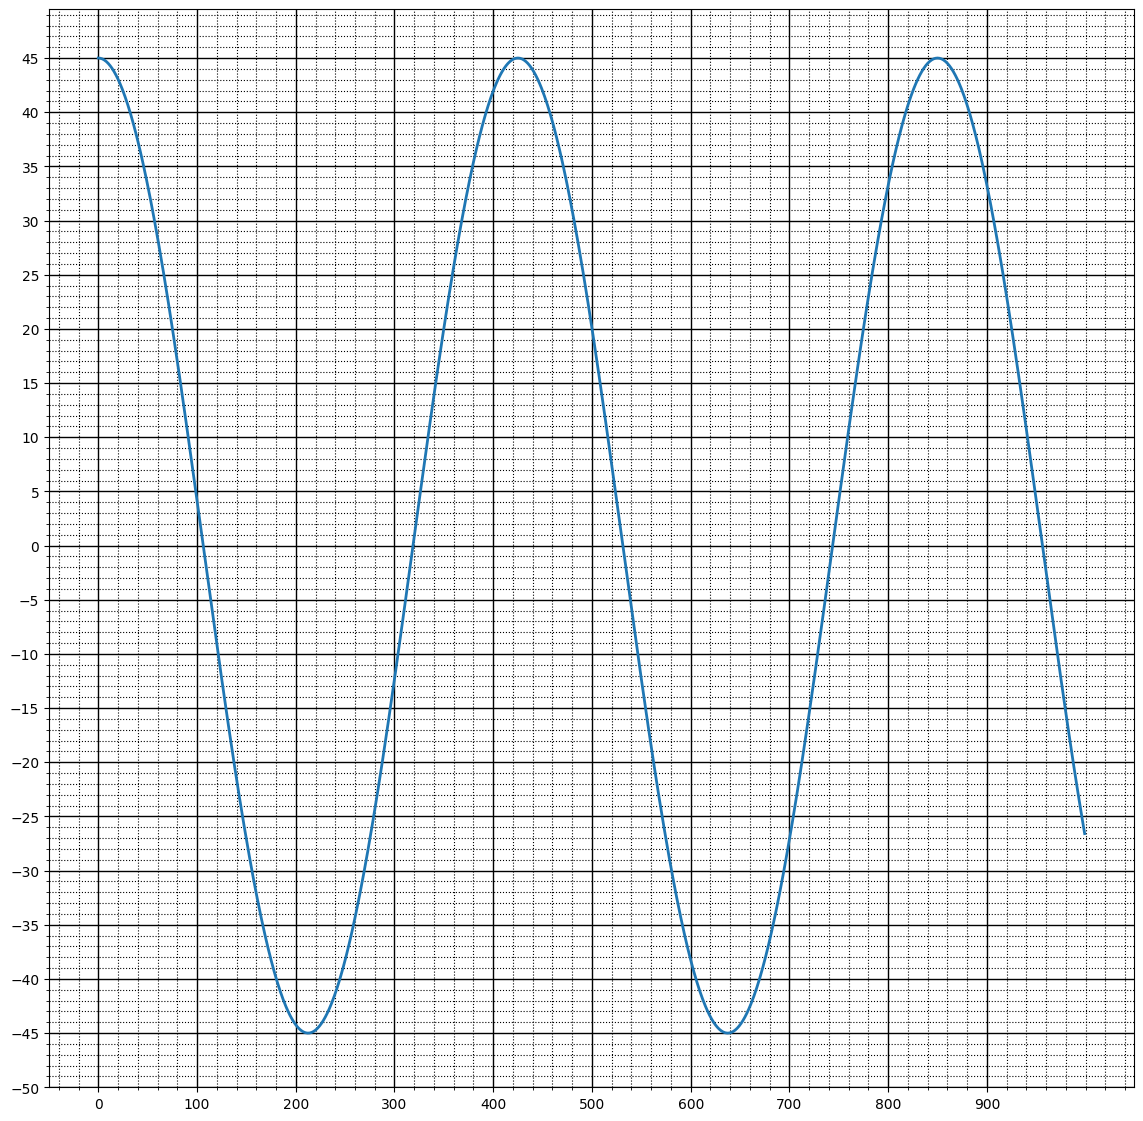

In [17]:
draw_signal(a)

In [18]:
assert len(a) == 1000
assert np.allclose(a, test_data["task2"]["a"], atol=1)
print("Ok!")

Ok!


**Подобранные коэффициенты для сигнала 'a':**

1. Амплитуда – $A = 45$, так как функция ограничена в $[-45, 45]$

2. Угловая частота – $\omega = \frac{2\pi}{T} = \frac{2\pi}{425} \approx 0.0148$, так как период $T = 425$

3. Фаза – $\phi = 0$, так как сдвига нет

### Сигнал ***b***

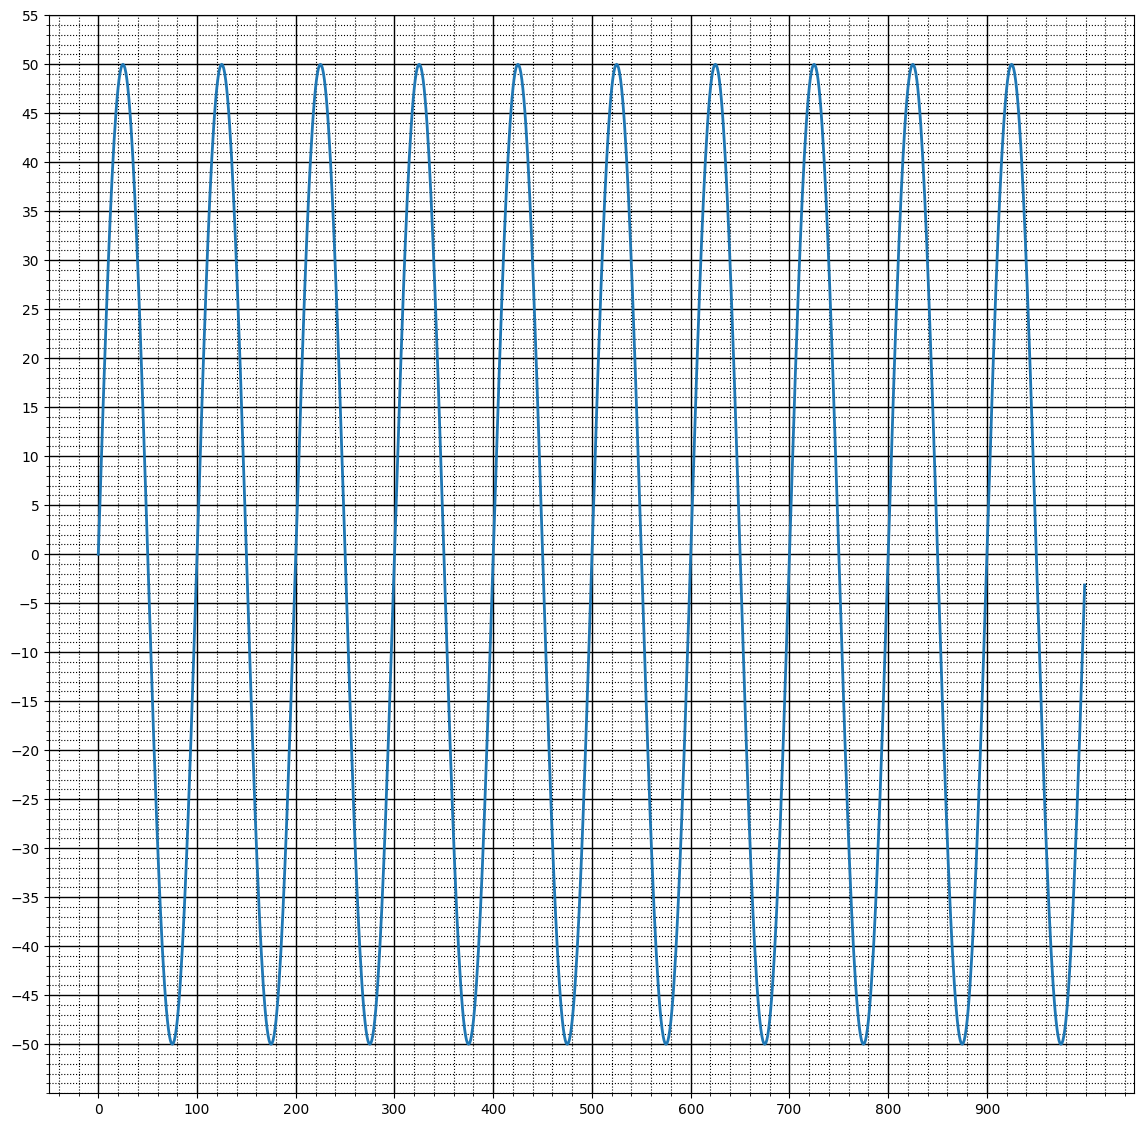

In [19]:
draw_signal(test_data['task2']['b'])

In [20]:
x = np.arange(0, 1000)
A = 50
phi = -np.pi / 2
T = 100
w = (2 * np.pi) / T
b = A * np.cos(w * x + phi)

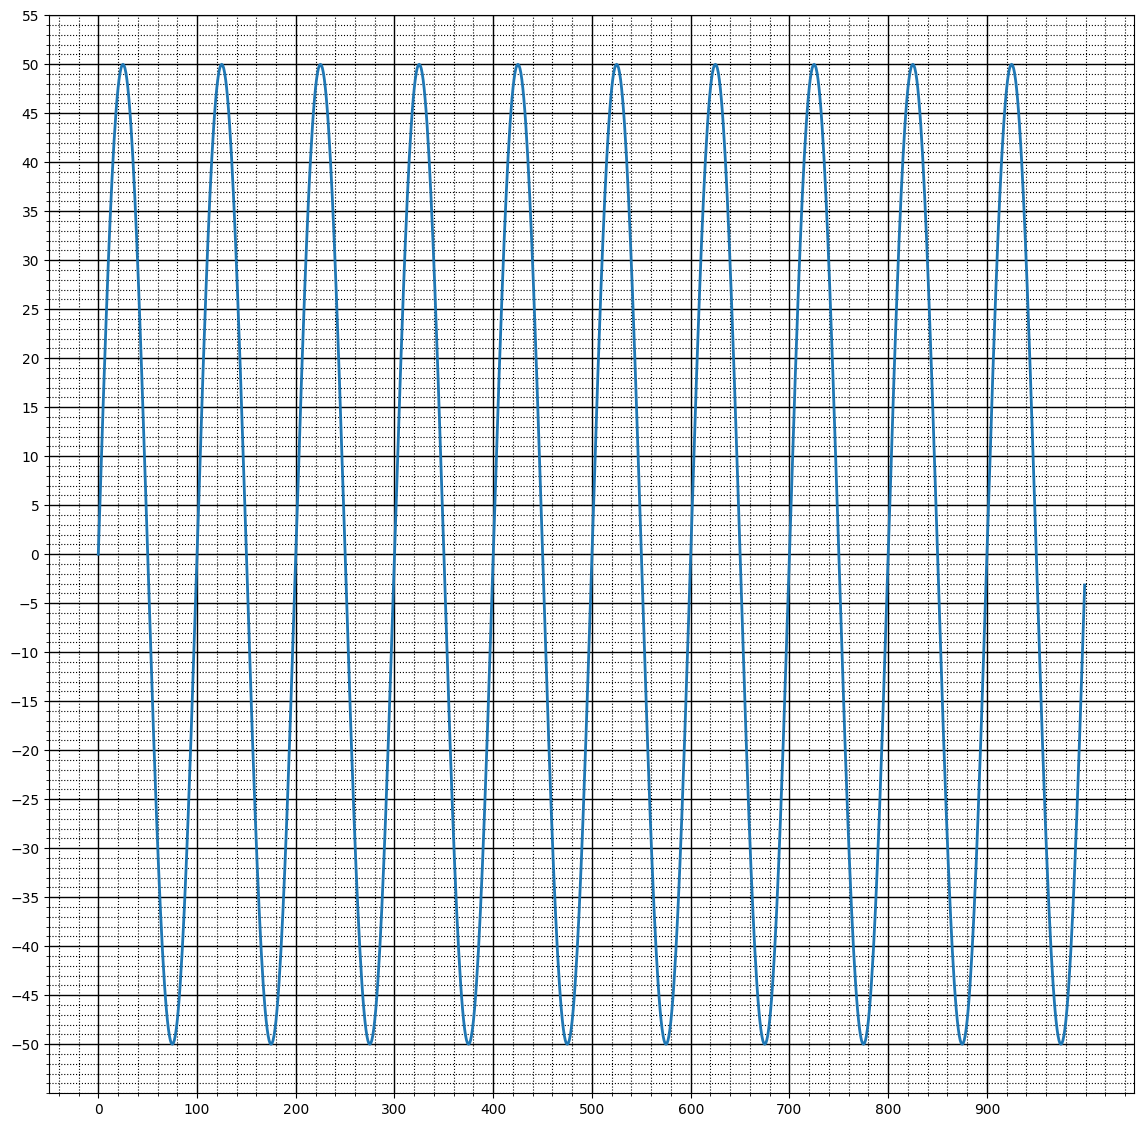

In [21]:
draw_signal(b)

In [22]:
assert len(b)== 1000
assert np.allclose(b, test_data["task2"]["b"], atol=1)
print("Ok!")

Ok!


**Подобранные коэффициенты для сигнала 'b':**

1. Амплитуда – $A = 50$, так как значения функции находятся в диапазоне $[-50, 50]$

2. Угловая частота – $\omega = \frac{2\pi}{T} = \frac{2\pi}{100} \approx 0.0628$, так как период $T = 100$

3. Фаза – $\phi = 0$, так как сигнал начинается с нуля (нет сдвига), а не с максимума

### Сигнал ***c***

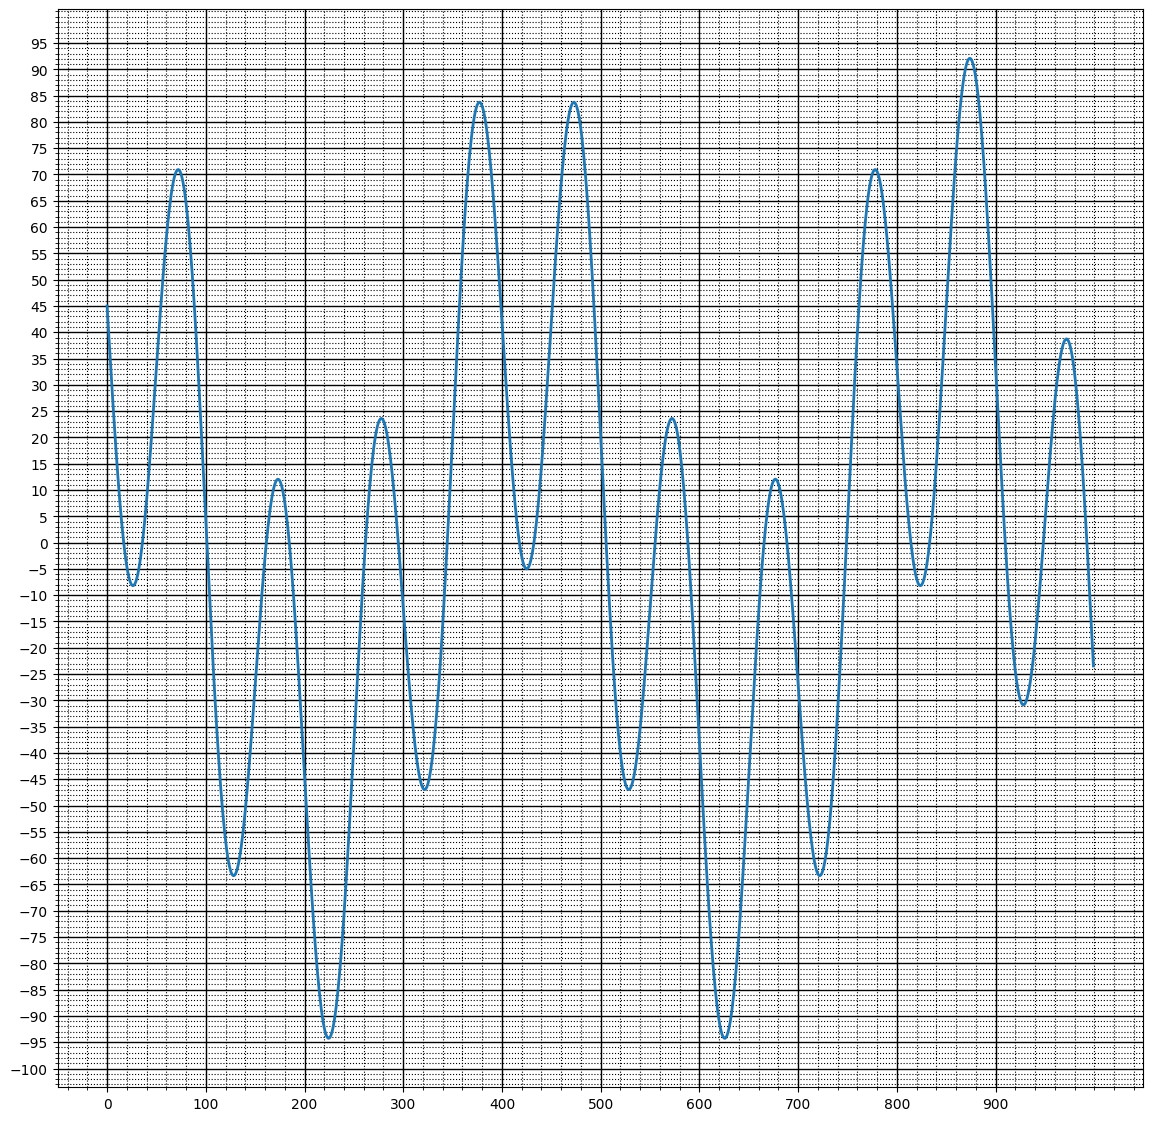

In [23]:
draw_signal(test_data['task2']['c'])

In [24]:
c = a - b

In [25]:
assert len(c)== 1000
assert np.allclose(c, test_data["task2"]["c"], atol=1)
print("Ok!")

Ok!


# Задание 3. Свертка (3 балла)

## Теория
Одна из наиболее частых операций, которая выполняется при обработке сигналов, это свёртка. Свёртка имеет много различных применений, например, с ее помощью можно убрать из сигнала шумы или применить к сигналу эффект эхо.


Свёртка — это математическая операция, применённая к двум функциям f и g и порождающая третью функцию. Операцию свёртки можно интерпретировать как «схожесть» одной функции с отражённой и сдвинутой копией другой.  Другими словами, преобразование свёртки однозначно определяет выходной сигнал y(t) для установленного значения входного сигнала x(t) при известном значении функции импульсного отклика системы h(t).

<!-- ![Convolution](resources/Convolution_of_box_signal_with_itself2.gif "Convolution") -->
![Convolution](resources/Convolution_of_box_signal_with_itself2.gif "Convolution")

Формула свёртки:
$$y_t=\frac{1}{2} \int_0^T x(\tau)h(t-τ)dτ$$
где $\tau$  - длительность импульсной переходной характеристики.

## Практика
Реализуйте операцию свёртки. Сравните её с существующей реализацией scipy.signal.convolve. Постройте графики фильтра, исходного сигнала и результата свертки.

In [26]:
def convolve(in1, in2):
    len_out = len(in1) + len(in2) - 1
    out = np.zeros(len_out)
    for i in range(len_out):
        for j in range(len(in1)):
            if 0 <= i - j < len(in2):
                out[i] += in1[j] * in2[i - j]
    return out

In [27]:
import scipy

In [28]:
def test_convolve(a, b, print_debug=False):
    my_result = convolve(a, b)
    scipy_result = scipy.signal.convolve(a, b, method='direct')
    if print_debug:
        print(f"Your result {my_result}")
        print(f"Scipy result {scipy_result}")
    assert np.allclose(my_result, scipy_result), f"Test {a} conv {b} failed"
    print("Ok!")

In [29]:
a = np.repeat([0,1,0], 10)
b = np.array([0,1,2,3,2,1,0])

In [43]:
test_convolve(a, b, print_debug=False)

Ok!


### Нарисуйте результат свертки a и b

Сигнал **а**

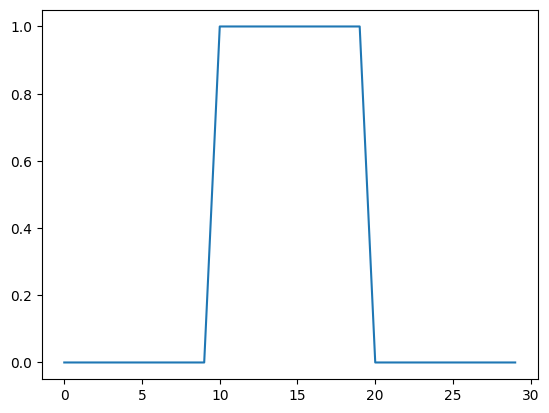

In [31]:
plt.plot(a)

Сигнал **b**

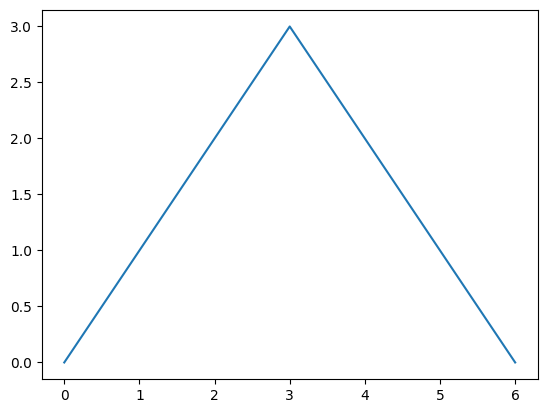

In [32]:
plt.plot(b)

Свертка **a** и **b**

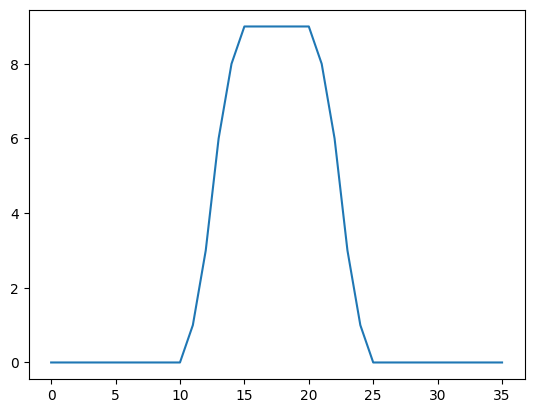

In [33]:
plt.plot(convolve(a,b))

Все 3 графика на одной картинке:

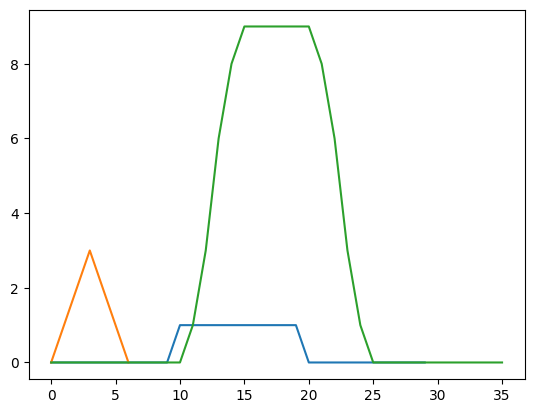

In [34]:
plt.plot(a)
plt.plot(b)
plt.plot(convolve(a,b))

# Задание 4. * Алгоритм Карплуса-Стронга

Реализуйте  [Алгоритм Карплуса-Стронга](https://en.wikipedia.org/wiki/Karplus%E2%80%93Strong_string_synthesis). В качестве фильтра используйте усреднитель двух смежных отсчетов. Проверьте результат.

Отрисуйте и воспроизведите полученный сигнал. На что влияют параметры генерации? Попробуйте имитировать звучание разных струн гитары.

In [35]:
def karplus_strong(noise, N):
    # Noise - input
    # N - number of samples to generate
    # return y - generated signal based on Noise
    y = np.zeros(N)
    L = len(noise)
    y[:L] = noise

    for n in range(L, N):
        y[n] = 0.5 * (y[n - L] + y[n - L - 1])

    return y

In [36]:
np.random.seed(seed=1)
sample_rate = 44100
frequency = 82.41
sec = 2
gen_len = sample_rate * sec
noise = (2 * np.random.uniform(-1, 1, int(sample_rate/frequency))) # [-1, 1]

gen_wav = karplus_strong(noise, gen_len)
assert np.allclose(gen_wav[:len(noise)], noise), "Generated signal must starting with noise"
assert np.allclose(gen_wav[len(noise)], (noise[0])/2), "Out of range samples eq 0."
assert np.allclose(gen_wav[len(noise)+1: 2*len(noise)], (noise[:-1] + noise[1:])/2), \
    "Bad requrent rule( 1 iteration)"
assert np.allclose(gen_wav[2*len(noise)], (noise[0]/2 + noise[-1])/2), \
    "Bad requrent rule( 2 iteration)"
assert np.allclose(gen_wav[2*len(noise)+2: 3*len(noise)], \
                   (((noise[:-1] + noise[1:])/2)[:-1] + ((noise[:-1] + noise[1:])/2)[1:])/2), \
    "Bad requrent rule( 3 iteration)"
print('All Ok!')

All Ok!


### Попробуем покрутить параметры генерации

Сгенерируем гитарные ноты:

In [37]:
sample_rate = 44100
duration_sec = 2
frequencies = [82.41, 110.00, 146.83, 196.00, 246.94, 329.63]  #ноты # E2, A2, D3, G3, B3, E4 соответственно

generated_signals = {}
for freq in frequencies:
    gen_len = int(sample_rate * duration_sec)
    noise = 2 * np.random.uniform(-1, 1, int(sample_rate / freq))
    signal = karplus_strong(noise, gen_len)
    generated_signals[freq] = signal

In [38]:
for freq, signal in generated_signals.items():
    print(f"Playing {freq} Hz")
    display(Audio(signal, rate=sample_rate))

Playing 82.41 Hz


Playing 110.0 Hz


Playing 146.83 Hz


Playing 196.0 Hz


Playing 246.94 Hz


Playing 329.63 Hz


Параметры генерации в алгоритме **Карплуса-Стронга** влияют на:

1. Длину начального шума, так как она определяет основную частоту ноты, ведь чем длиннее шум, тем ниже частота основной гармоники

2. Коэффициент фильтра (усреднителя двух соседних отсчетов), т.к. он влияет на скорость затухания сигнала. Меньшее значение приводит к более быстрому затуханию, а большее наоборот — к более длительному звучанию

3. Частоту дискретизации, которая задает временную точность сигнала и также влияет на точность воспроизведения основной частоты

4. Продолжительность генерации определяет, сколько отсчетов звука будет сгенерировано(просто длительность ноты)

Визуализируем затухание амплитуды:

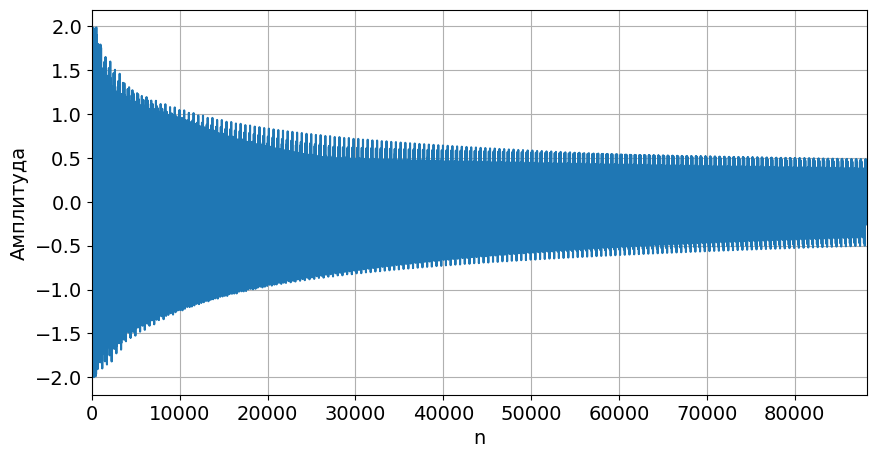

In [39]:
plt.figure(figsize=(10,5))
plt.xlabel('n', fontsize=14)
plt.ylabel('Амплитуда', fontsize=14)
plt.xlim(0, gen_len)
plt.plot(np.linspace(0, gen_len+1, gen_len), gen_wav)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()

Визуализируйте затухание амплитуд гитарных нот:

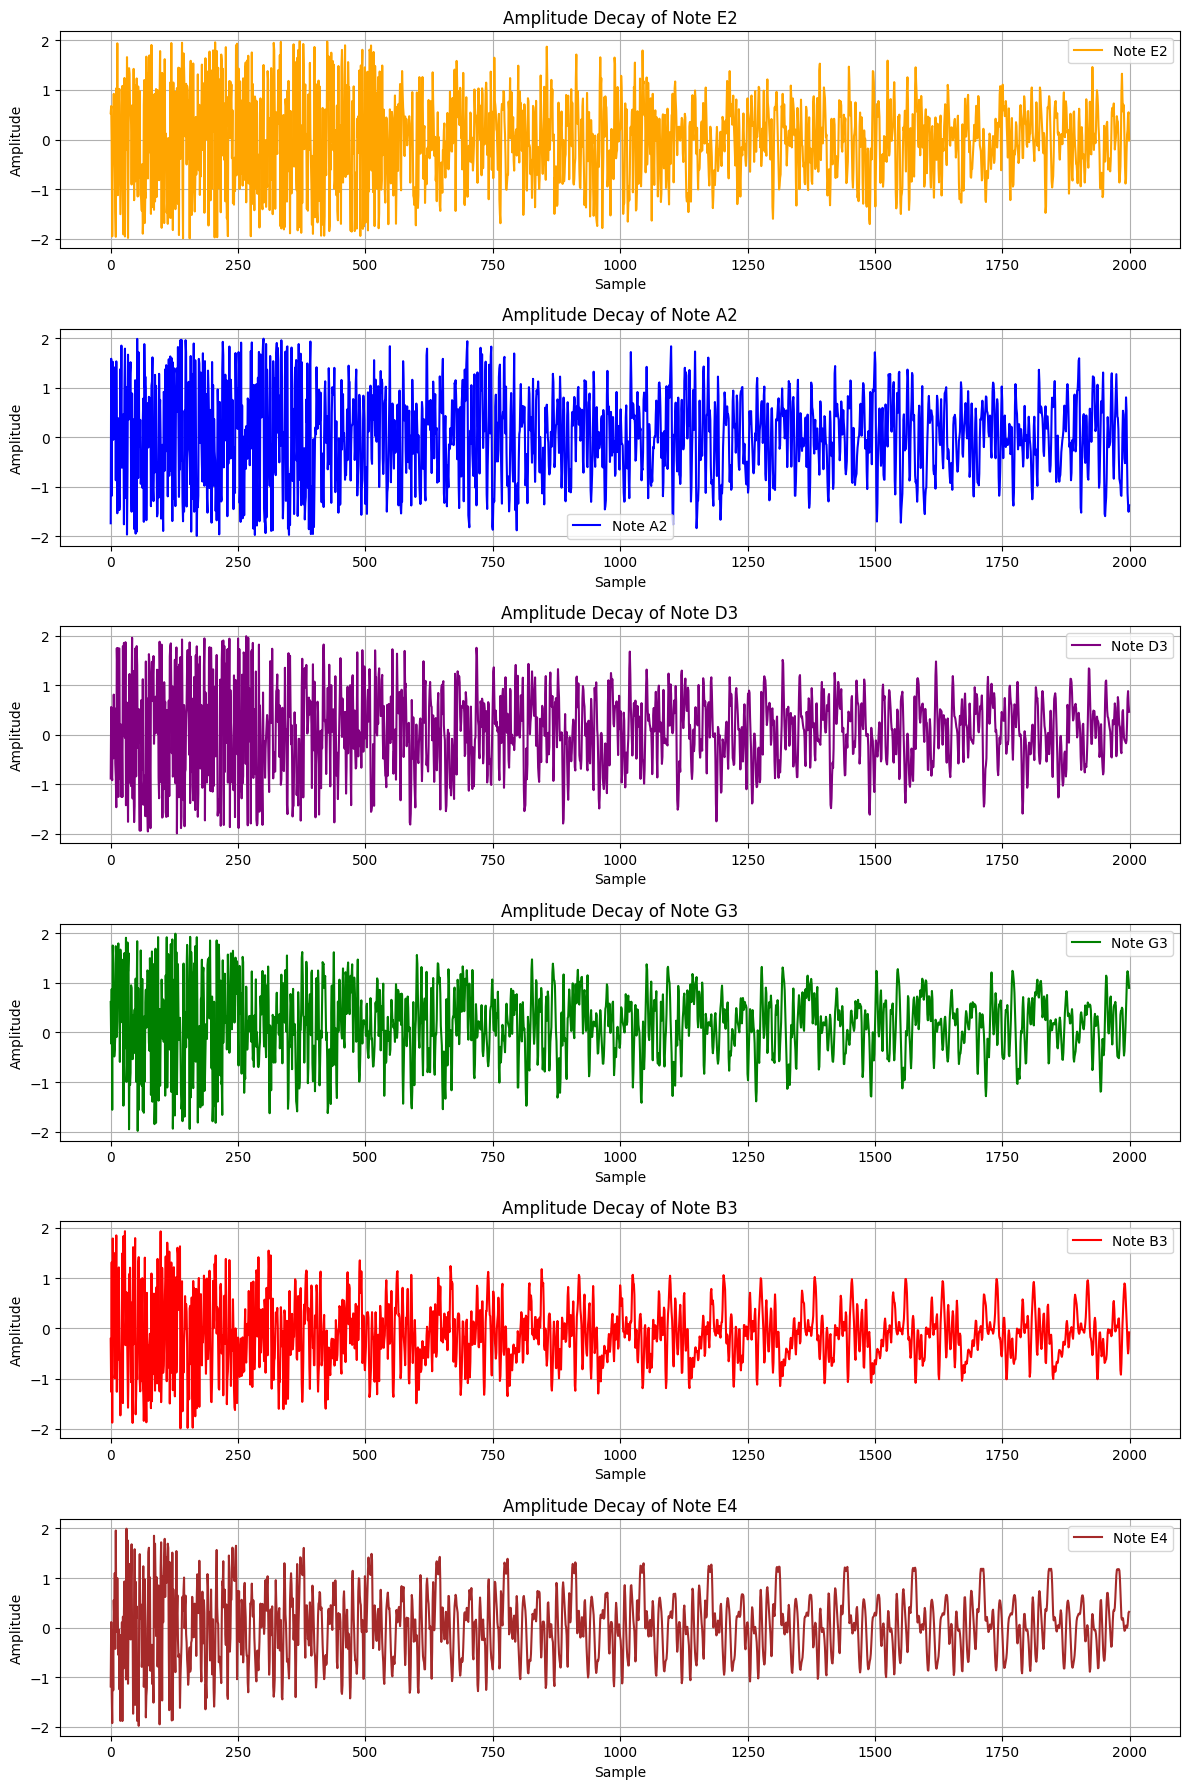

In [40]:
plt.figure(figsize=(12, 18))

notes = [82.41, 110.00, 146.83, 196.00, 246.94, 329.63]
colors = ['orange', 'blue', 'purple', 'green', 'red', 'brown']
labels = ['E2', 'A2', 'D3', 'G3', 'B3', 'E4']

for i, freq in enumerate(notes, 1):
    plt.subplot(6, 1, i)
    plt.plot(generated_signals[freq][:2000], label=f'Note {labels[i-1]}', color=colors[i-1])
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.title(f'Amplitude Decay of Note {labels[i-1]}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

Захотелось ноты как-то соединить)

In [41]:
note_duration_sec = 0.4
melody_sequence = [82.41, 110.00, 146.83, 196.00, 246.94, 329.63, 196.00, 146.83]

melody_signal = np.array([])

for freq in melody_sequence:
    gen_len = int(sample_rate * note_duration_sec)
    noise = 2 * np.random.uniform(-1, 1, int(sample_rate / freq))
    note_signal = karplus_strong(noise, gen_len)
    melody_signal = np.concatenate((melody_signal, note_signal))

print("Playing melody with short notes...")
display(Audio(melody_signal, rate=sample_rate))

Playing melody with short notes...


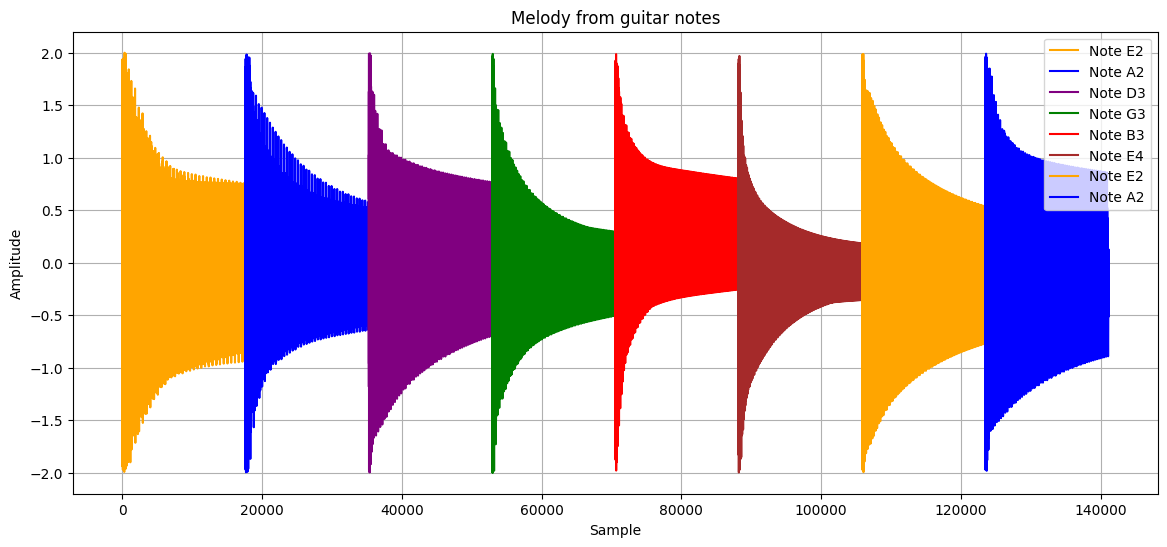

In [42]:
plt.figure(figsize=(14, 6))
start = 0
for i, freq in enumerate(melody_sequence):
    end = start + int(sample_rate * note_duration_sec)
    color_idx = i % len(colors)
    label_idx = int(i % len(labels))
    plt.plot(np.arange(start, end), melody_signal[start:end], color=colors[color_idx], label=f'Note {labels[label_idx]}')
    start = end

plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.title('Melody from guitar notes')
plt.legend()
plt.grid(True)
plt.show()